In [ ]:
# Clone repo (if running in Colab)
!git clone https://github.com/LizaGenke/Chemometric-approaches-to-hyperspectral-processing.git

# Navigate into the cloned repository
%cd Chemometric-approaches-to-hyperspectral-processing

# Install dependencies
!pip install -r requirements.txt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
# Define the path to your data and result folders in Google Drive
data_path = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing/data'
results_dir = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing_Results'
os.makedirs(results_dir, exist_ok=True)

# Robust analysis

Even having a few outliers in training data can significantly distort calibration models. This notebook will walk through methods that help make analysis more resilient. In particular we will consider robust PC regression and robust PLSR.

## Loading the data

We start by loading the preprocessed hyperspectral reflectance data and corresponding reference values. These reference values represent the dry matter content for each sample and serve as our target variable for regression.

In [ ]:
import numpy as np

kiwi_spectra = np.loadtxt(f"{results_dir}/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt(f"{data_path}/reference.csv", delimiter=",")
wl = np.loadtxt(f"{results_dir}/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]
reference_values = np.expand_dims(reference_values, axis=1)
reference_values.shape

(180, 1)

## Pre-processing

Let's process our data in the same way as we did in spectral analysis notebook to remove unwanted variability in the spectra, such as scattering effects and noise.

In [2]:
import nippy

preprocessing_pipeline = {'MSC': None, 
                          'SAVGOL': 
                          {'deriv_order': 2, 
                           'filter_win': 13, 
                           'poly_order': 2}, 
                           'SNV': {}}

wl, kiwi_spectra_processed = nippy.run_pipeline(wl, kiwi_spectra.T, preprocessing_pipeline)
kiwi_spectra_processed = kiwi_spectra_processed.T

## Data partition

To evaluate the generalization performance of our models, we split the dataset into a calibration (training) and a test set using the Kennard-Stone algorithm.

In [3]:
import kennard_stone as ks

X_cal_ks, X_test_ks, y_cal_ks, y_test_ks = ks.train_test_split(kiwi_spectra_processed, reference_values, test_size = 0.2, random_state=1)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-08-26 16:53:23,743 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-08-26 16:53:23,747 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

## Robust PCA

PCA is very susceptible to the outliers. If we modify just one sample the results already are going to be quite different. Let's artificially introduce some outliers in our dataset and see how it influences the model.

In [4]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random

We'll select a few indices at random for X and y. For robust PCR we will only experiment with outliers in spectra since by design simple linear regression built on principal components cannot deal with outliers.

In [5]:
random.seed(42)
number_of_outliers_x = 5
number_of_outliers_y = 5
indices_of_outliers = random.sample(range(X_cal_ks.shape[0]), number_of_outliers_x + number_of_outliers_y)
indices_of_outliers_x = indices_of_outliers[:number_of_outliers_x]
indices_of_outliers_y = indices_of_outliers[number_of_outliers_x:]

In [6]:
X_copy = np.copy(X_cal_ks)
X_copy[indices_of_outliers_x,:] = X_copy[indices_of_outliers_x,:] * 5

In [7]:
pipe1 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA(random_state=42))])
pipe2 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA(random_state=42))])
 
pipe1.fit(X_cal_ks)
pipe2.fit(X_copy)

Pipeline(steps=[('scaler', StandardScaler(with_std=False)),
                ('pca', PCA(random_state=42))])

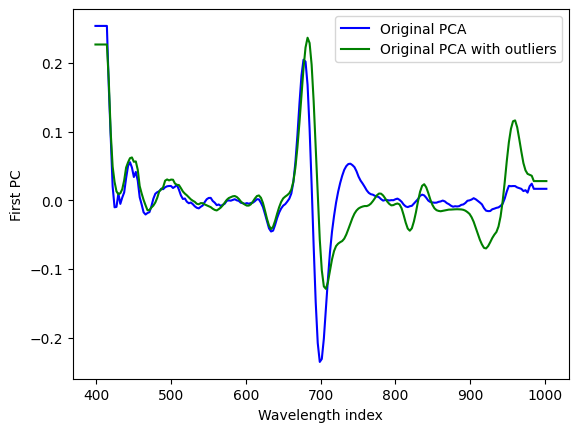

In [8]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

To reduce the influence of outliers, we use a robust estimator of covariance (Minimum Covariance Determinant). This method estimates the covariance matrix based on the most representative subset of the data. The support_fraction parameter controls how much of the data is considered "clean."

In [9]:
from sklearn.covariance import MinCovDet

# Fit MinCovDet on the data with outliers
robust_cov = MinCovDet(support_fraction=0.3, random_state=42).fit(X_copy)
V_robust = robust_cov.covariance_

# Calculate eigenvalues and eigenvectors of the robust covariance matrix
values_robust, vectors_robust = np.linalg.eig(V_robust)
sorted_values_robust = np.argsort(values_robust)[::-1]
sorted_vectors_robust = vectors_robust[:, sorted_values_robust]

first_pc_robust = sorted_vectors_robust[:, 0]
first_pc_robust /= np.linalg.norm(first_pc_robust)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


In [10]:
first_pc_robust *= -1 # Eigenvectors are unique up to a sign. Sometimes you might want to flip it

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


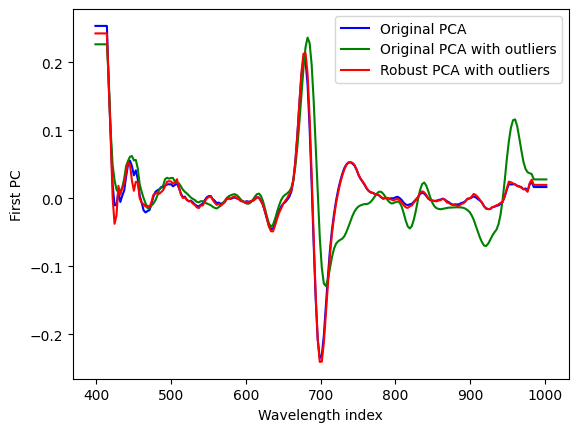

In [11]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.plot(wl, first_pc_robust, 'r', label="Robust PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

In [12]:
support_fraction=0.3

Now, we apply Principal Component Regression (PCR) using both standard PCA and robust PCA. We'll compare their predictive performance to see whether the robust method improves results in the presence of outliers.

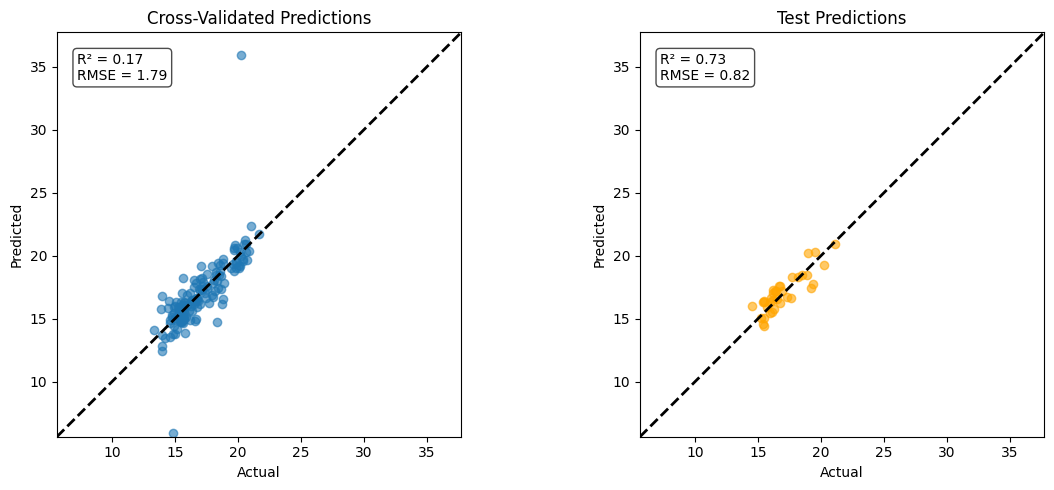

In [13]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict
from helperfunctions.plot_functions import plot_cv_vs_test

pca = PCA(random_state=42)
pc=90
standard_scaler_cal = StandardScaler()
Xstd = standard_scaler_cal.fit_transform(X_copy)
Xreg = pca.fit_transform(Xstd)[:,:pc]
model = linear_model.LinearRegression()
model.fit(Xreg, y_cal_ks)

y_cv = cross_val_predict(model, Xreg, y_cal_ks, cv=10)

X_test_std = standard_scaler_cal.transform(X_test_ks)
X_test_reg = pca.transform(X_test_std)[:,:pc]

y_test_pred = model.predict(X_test_reg)

plot_cv_vs_test(y_cal_ks, y_cv, y_test_ks, y_test_pred)

Let's make a function that encapsulates robust PCR: it uses robust PCA to extract components and performs linear regression on those components. The test data is transformed using the same scaling and projection for evaluation.

In [14]:
def robust_pcr_with_test_predefined(X_train, X_test, y_train, pc, support_fraction=0.7):
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)

    robust_cov = MinCovDet(support_fraction=support_fraction, random_state=42).fit(X_train_std)
    V_robust = robust_cov.covariance_
    values_robust, vectors_robust = np.linalg.eig(V_robust)

    sorted_indices = np.argsort(values_robust)[::-1]
    sorted_vectors = vectors_robust[:, sorted_indices]
    components = sorted_vectors[:, :pc]

    X_train_reg = np.real(X_train_std @ components)
    X_test_std = scaler.transform(X_test)
    X_test_reg = np.real(X_test_std @ components)

    regr = linear_model.LinearRegression()
    regr.fit(X_train_reg, y_train)

    y_train_cv = cross_val_predict(regr, X_train_reg, y_train, cv=10)
    y_test_pred = regr.predict(X_test_reg)

    return y_train_cv, y_test_pred

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


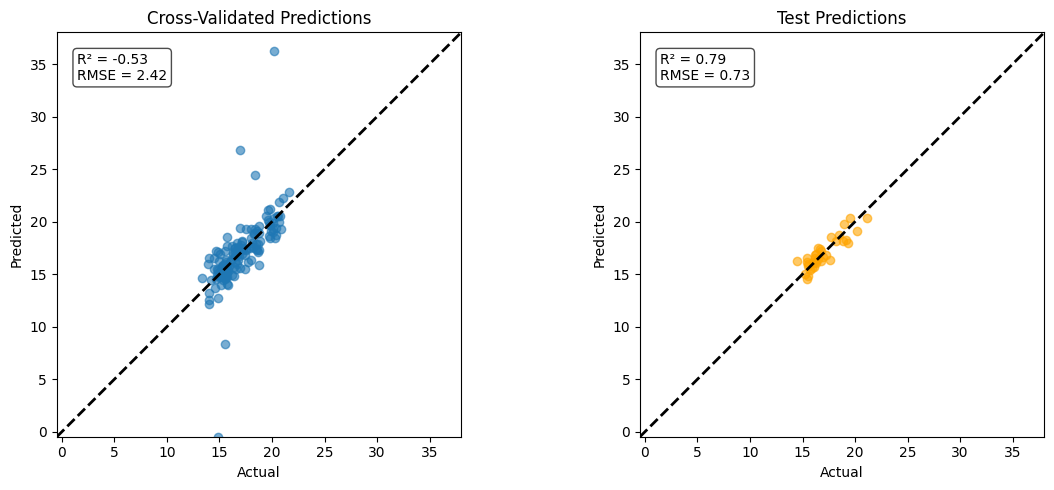

In [15]:
y_train_cv, y_test_pred = robust_pcr_with_test_predefined(X_copy, X_test_ks, y_cal_ks, support_fraction=support_fraction, pc=pc)
plot_cv_vs_test(y_cal_ks, y_train_cv, y_test_ks, y_test_pred)

We can see that the result is slightly better if we apply robust PCR. But this approach is not able to deal with outliers in response variable. And we have to guess the support fraction.

## Robust PLSR

Let's look at robust implementation of robust PLSR, using https://github.com/puneetmishra2/IRNPLS/tree/main

In [16]:
y_copy = np.copy(y_cal_ks)
y_copy[indices_of_outliers_y,:] = y_copy[indices_of_outliers_y,:]*2

In [17]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin

class irpls(BaseEstimator, RegressorMixin):
    def __init__(self, lvs=2, alpha=4.685):
        self.lvs = lvs
        self.alpha = alpha
        self.beta = None
        self.weights = None
        self.attributes = None
        self.X_median = None
        self.y_median = None

    def fit(self, X, Y):
        if X.shape[0] != Y.shape[0]:
            raise ValueError("X and Y must have the same number of samples.")
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        elif Y.shape[0] == 1:
            Y = Y.T

        self.X_median = np.median(X, axis=0)
        self.y_median = np.median(Y, axis=0)
        X = X - self.X_median
        Y = Y - self.y_median

        n_samples, n_features = X.shape
        n_responses = Y.shape[1]
        lvs = min(self.lvs, n_samples, n_features)

        q = np.zeros((n_responses, lvs))
        T = np.zeros((n_samples, lvs))
        weights = np.zeros((lvs, n_samples))
        w = np.zeros((n_features, lvs))
        Pb = np.zeros((n_features, lvs))

        for i in range(lvs):
            D = (np.eye(n_samples)) / n_samples
            crit = 1
            while crit > 1e-5:
                vt = X.T @ D @ Y
                v = vt.copy()
                t_temp = X @ v / np.linalg.norm(X @ v)
                q_temp = (Y.T @ D) @ t_temp
                r = Y - np.outer(t_temp, q_temp)
                lo = 1 - t_temp**2
                r = r / np.sqrt(lo)
                mad_r = np.median(np.abs(r - np.median(r, axis=0)), axis=0)
                r = r * (0.6745 / self.alpha) / mad_r
                temp_D = (1 - r**2)**2
                temp_D[np.abs(r) >= 1] = 0
                temp_D = np.prod(temp_D, axis=1)
                crit = np.sum(np.abs(temp_D) - np.abs(np.diag(D)))
                D = np.diag(temp_D)

            weights[i, :] = np.diag(D)
            vt = X.T @ D @ Y
            vt = vt.flatten()
            w[:, i] = vt
            t = X @ w[:, i]
            t /= np.linalg.norm(t)
            T[:, i] = t
            q[:, i] = (Y.T @ D) @ t
            Pb[:, i] = (X.T @ D) @ t
            X = X - np.outer(t, Pb[:, i])
            Y = Y - np.outer(t, q[:, i])
            w[:, i] = w[:, i] / np.linalg.norm(w[:, i])

        PtW = np.triu(Pb.T @ w)
        beta = []

        for i in range(n_responses):
            w_div_PtW = w @ np.linalg.inv(PtW)
            temp = w_div_PtW * q[i, :]
            temp_cumsum = np.cumsum(temp, axis=1)
            intercepts = self.y_median[i] - self.X_median @ temp_cumsum
            beta_i_all = np.vstack([intercepts[np.newaxis, :], temp_cumsum])
            beta.append(beta_i_all)

        self.beta = beta
        self.weights = weights
        self.attributes = {'T': T, 'Pb': Pb, 'W': w, 'PtW': PtW}

    def predict(self, X, component=None):
        if self.beta is None:
            raise RuntimeError("You must call fit() before predict().")
        if component is None:
            component = self.lvs - 1

        beta_k = self.beta[0][:, component]
        intercept = beta_k[0]
        coefs = beta_k[1:]
        return X @ coefs + intercept


Results of normal PLS without outliers


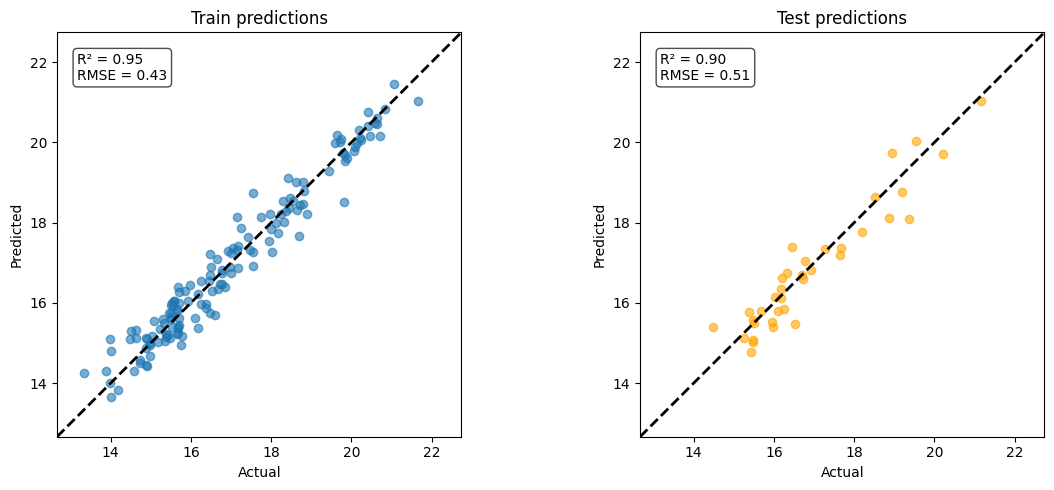

In [18]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=11)
pls.fit(X=X_cal_ks, y=y_cal_ks)
y_pred_pls_cv = pls.predict(X_cal_ks)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS without outliers")
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test, plot_titles=["Train predictions", "Test predictions"])

Results of IRPLS without outliers


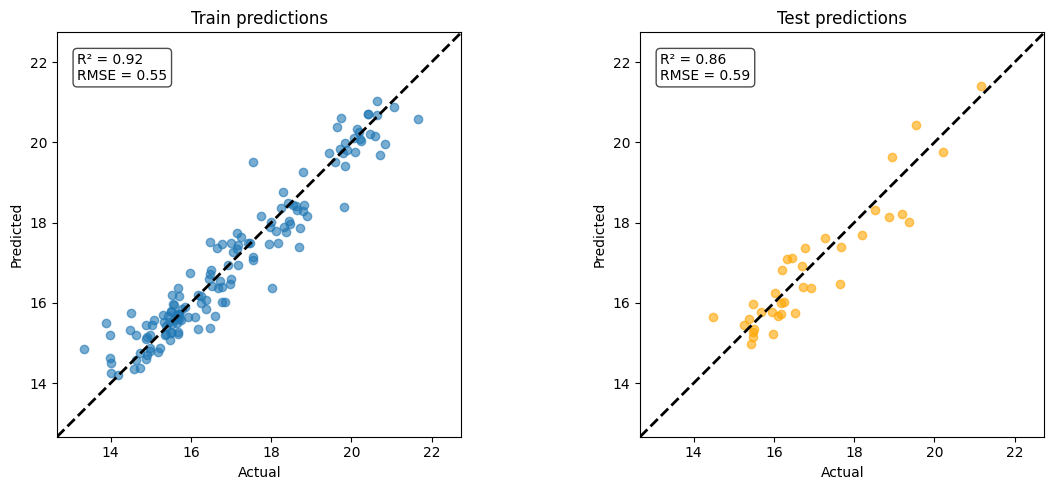

In [19]:
model = irpls(lvs=11, alpha=4.685)
model.fit(X_cal_ks, y_cal_ks)

Y_pred_train = model.predict(X_cal_ks)
Y_pred_test = model.predict(X_test_ks)

print("Results of IRPLS without outliers")
plot_cv_vs_test(y_cal_ks, Y_pred_train, y_test_ks, Y_pred_test, plot_titles=["Train predictions", "Test predictions"])

The results when there are no strong outliers are better in the normal PLS resgressor. But the situation is different when there are strong outliers in X and/or Y.

Results of normal PLS with outliers in X


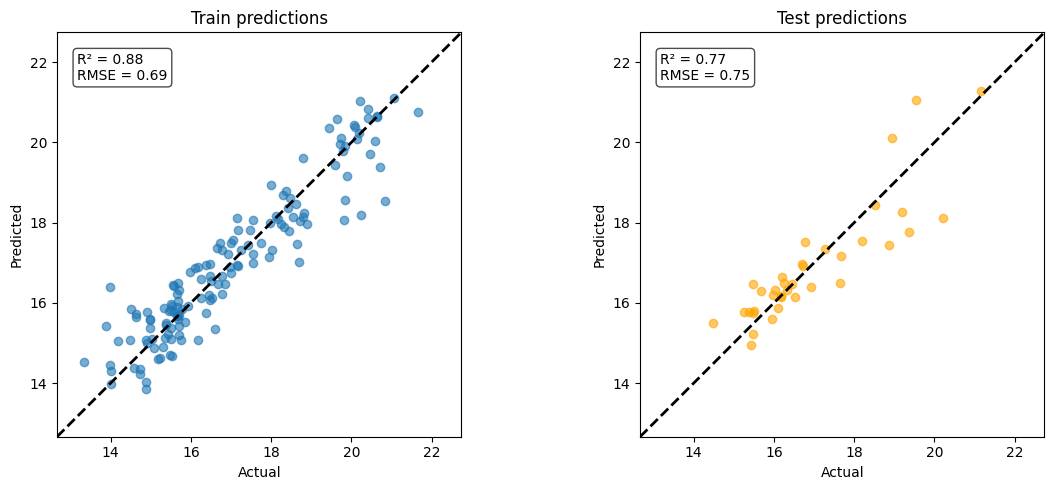

In [20]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=11)
pls.fit(X=X_copy, y=y_cal_ks)
y_pred_pls_cv = pls.predict(X_copy)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS with outliers in X")
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test, plot_titles=["Train predictions", "Test predictions"])

Results of IRPLS with outliers in X


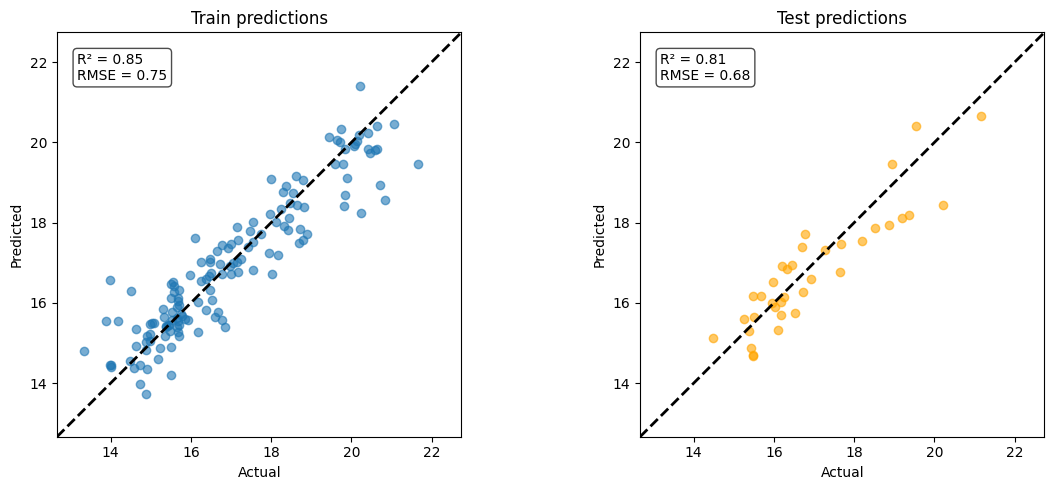

In [21]:
import matplotlib.pyplot as plt
model = irpls(lvs=11, alpha=4.685)
model.fit(X_copy, y_cal_ks)

Y_pred_train = model.predict(X_copy)
Y_pred_test = model.predict(X_test_ks)
print("Results of IRPLS with outliers in X")
plot_cv_vs_test(y_cal_ks, Y_pred_train, y_test_ks, Y_pred_test, plot_titles=["Train predictions", "Test predictions"])

We can see that  normal PLSR overfits more ans IRPLS is less susceptible to outliers in training data. It can also deal well with outliers in Y, as you can see below

Results of normal PLS with outliers in X and Y


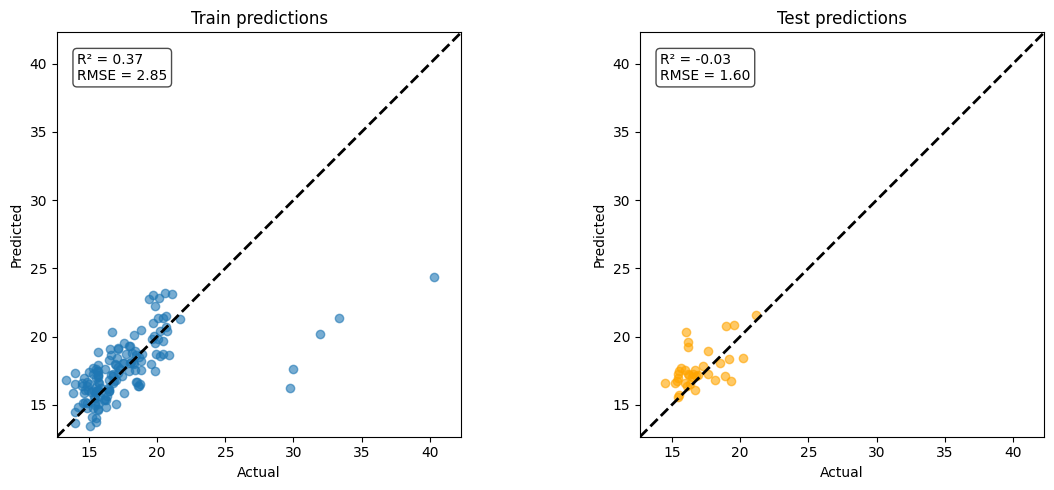

In [22]:
pls = PLSRegression(n_components=11)
pls.fit(X=X_copy, y=y_copy)
y_pred_pls_cv = pls.predict(X_copy)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS with outliers in X and Y")
plot_cv_vs_test(y_copy, y_pred_pls_cv, y_test_ks, y_pred_pls_test, ["Train predictions", "Test predictions"])

Results of IRPLS with outliers in X and Y


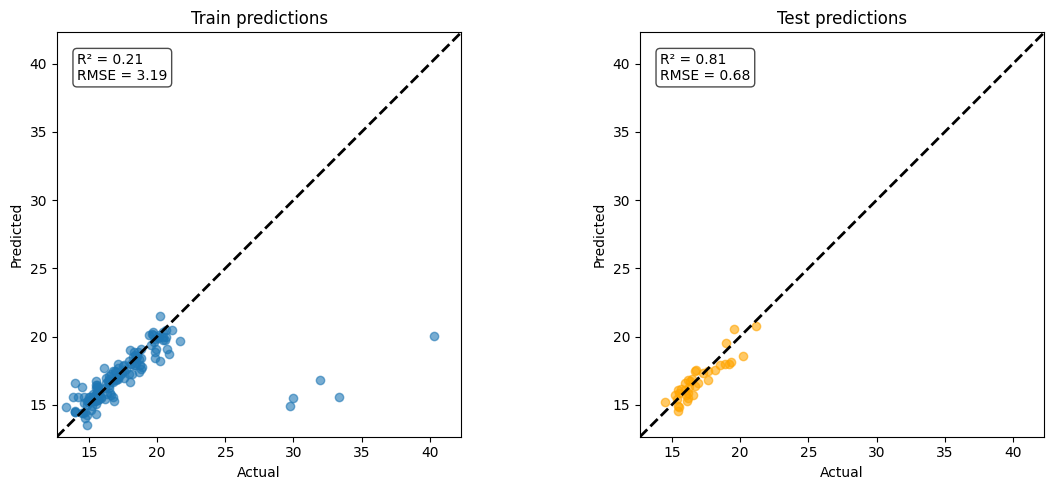

In [23]:
model = irpls(lvs=11, alpha=4.685)
model.fit(X_copy, y_copy)

Y_pred_train = model.predict(X_copy)
Y_pred_test = model.predict(X_test_ks)
print("Results of IRPLS with outliers in X and Y")
plot_cv_vs_test(y_copy, Y_pred_train, y_test_ks, Y_pred_test, plot_titles=["Train predictions", "Test predictions"])

To get the best results we of course have to optimize the parameters used in the regression algorithm. You can do so by using the function below:

In [24]:
from sklearn.metrics import median_absolute_error

def optimise_irpls_cv_test(X_train, y_train, X_test, y_test, max_n_lvs, alphas):
    mdae = np.zeros([max_n_lvs, len(alphas)])
    mdae_test = np.zeros([max_n_lvs, len(alphas)])
    mdae_train = np.zeros([max_n_lvs, len(alphas)])

    lvs = np.arange(1, max_n_lvs + 1)

    for i in lvs:
        for j,alpha in enumerate(alphas):
            model = irpls(lvs=i, alpha=alpha)
            y_cv = cross_val_predict(model, X_train, y_train, cv=10)
            mdae[i-1, j] = median_absolute_error(y_cv, y_train)

            model = irpls(lvs=i, alpha=alpha)
            model.fit(X_train, y_train)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
            mdae_train[i-1, j] = median_absolute_error(y_train, y_train_pred)
            mdae_test[i-1, j] = median_absolute_error(y_test, y_test_pred)

    idx = np.unravel_index(np.argmin(mdae), mdae.shape)
    best_n, best_a = idx[0]+1, alphas[idx[1]]
    print(f"Suggested components: {best_n}, alpha: {best_a}")

    # plot
    plt.figure(figsize=(8,5))
    plt.plot(range(1, max_n_lvs+1), mdae_train[:, idx[1]], 'o-', label='Train Median absolute error')
    plt.plot(range(1, max_n_lvs+1), mdae[:, idx[1]], 'o-', label='CV Median absolute error')
    plt.plot(range(1, max_n_lvs+1), mdae_test[:, idx[1]], 'o-', label='Test Median absolute error')
    plt.xlabel('Number of components')
    plt.ylabel('Median absolute error')
    plt.title(f'IRPLS (alpha={best_a})')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_n, best_a

Suggested components: 29, alpha: 6


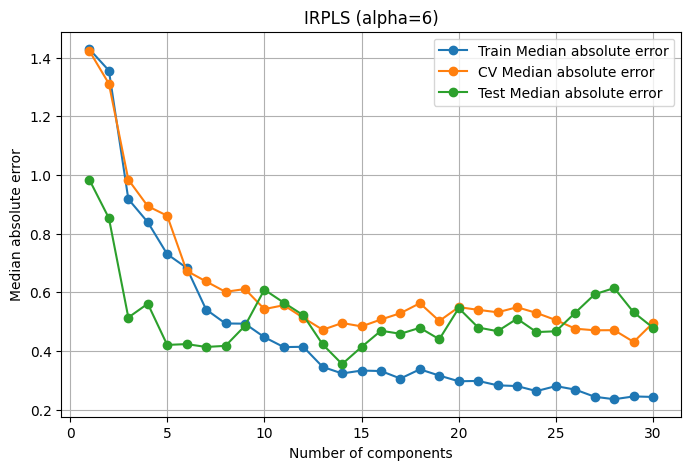

In [25]:
opt_n_lvs, opt_alpha = optimise_irpls_cv_test(X_copy, y_copy, X_test_ks, y_test_ks, max_n_lvs=30, alphas=[2, 3, 4, 5, 6, 7])

Results of IRPLS with outliers in X and Y


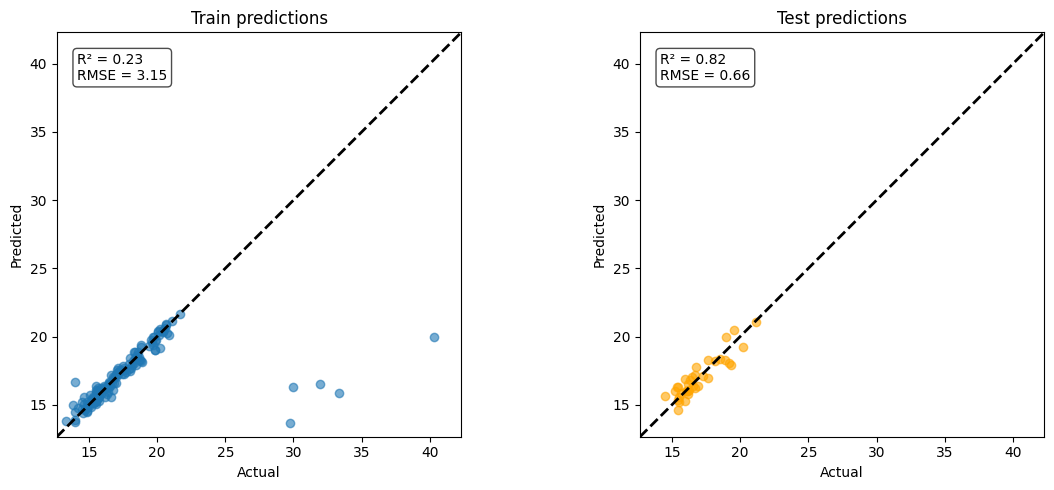

In [26]:
model = irpls(lvs=opt_n_lvs, alpha=opt_alpha)
model.fit(X_copy, y_copy)

Y_pred_train = model.predict(X_copy)
Y_pred_test = model.predict(X_test_ks)
print("Results of IRPLS with outliers in X and Y")
plot_cv_vs_test(y_copy, Y_pred_train, y_test_ks, Y_pred_test, plot_titles=["Train predictions", "Test predictions"])

And sometimes by luck you have pretty good results with your initial parameters, and there is not much to gain with optimizing all the parameters 😊